# Function 8 — 8D Black-Box Optimisation

**Surrogate 1:** SVM (RBF kernel), trained on all points — classifies
promising / poor regions
**Surrogate 2:** Neural network ensemble, trained only on the promising points
— models the Y surface there
**Acquisition:** two-stage UCB — SVM gate, then `nn_mean + β · nn_std`

---

Eight hyperparameters in [0, 1], returning a performance score. One query per
week, five rounds completed.

**This is the only function where the Gaussian Process was abandoned
entirely.** The reasoning is in section 3, and section 5 tests whether the
replacement actually works.

## Problem characteristics

| Property | Value | Implication |
|---|---|---|
| Dimensions | 8D | Past the practical limit for GP kernel fitting at this sample size |
| Dataset | 40 supplied, 45 total | Extremely sparse in eight dimensions |
| Y range | 5.59 to 9.60 | Compact, roughly 1.7× — no transform needed |
| Grid | 6⁸ ≈ 1.68M | A grid of 10 per axis would be 100M points — impractical |
| Noise | Stochastic evaluation | Moderate, from mini-batch sampling and random seeds |

### A note on the inputs

The eight inputs are named `lr`, `batch`, `layers`, `dropout`, `reg`,
`activation`, `optimizer`, `init_range`, but **all values are normalised to
[0, 1]**. Without the original search-space bounds, a value of 0.056 for `lr`
means "near the low end of whatever range lr was sampled from" — not a learning
rate of 0.056. Every reading below is relative.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from itertools import combinations

import warnings
warnings.filterwarnings("ignore")

## 1. Data

Loaded from `../data/function_8.csv` rather than pasted inline.

In the original script `X` had grown to 46 rows while `Y` had 45 values — a
pending round-6 query had been added before its result came back. Every model
fit in the pipeline fails on that mismatch.

In [2]:
# -----------------------------------------------------------------
#  DATA
# -----------------------------------------------------------------
df = pd.read_csv("../data/function_8.csv", float_precision="round_trip")

PARAMS = ["lr", "batch", "layers", "dropout",
          "reg", "activation", "optimizer", "init_range"]

X    = df[[f"x{i+1}" for i in range(8)]].values
Y    = df["y"].values
week = df["week"].values

print(f"X shape : {X.shape}")
print(f"Y shape : {Y.shape}")
print(f"Y range : [{Y.min():.4f},  {Y.max():.4f}]")
print(f"Rounds present: {sorted(set(week))}")

readable = pd.DataFrame(X, columns=PARAMS)
readable["score"] = Y
readable["week"]  = week
readable.tail(6)

X shape : (45, 8)
Y shape : (45,)
Y range : [5.5922,  9.5985]
Rounds present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,lr,batch,layers,dropout,reg,activation,optimizer,init_range,score,week
39,0.481245,0.102461,0.219486,0.677322,0.247509,0.244341,0.163825,0.715962,9.183005,0
40,0.202424,0.639510,0.410646,0.482822,0.798912,0.646056,0.275619,0.304395,9.350834,1
41,0.056447,0.055950,0.023928,0.238785,0.403935,0.801055,0.498307,0.899850,9.589691,2
42,0.202109,0.641495,0.402226,0.485164,0.789443,0.660532,0.278216,0.292581,9.355412,3
43,0.200817,0.638643,0.412485,0.481958,0.792244,0.652449,0.269131,0.291889,9.348988,4
44,0.000000,0.600000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,6.418300,5


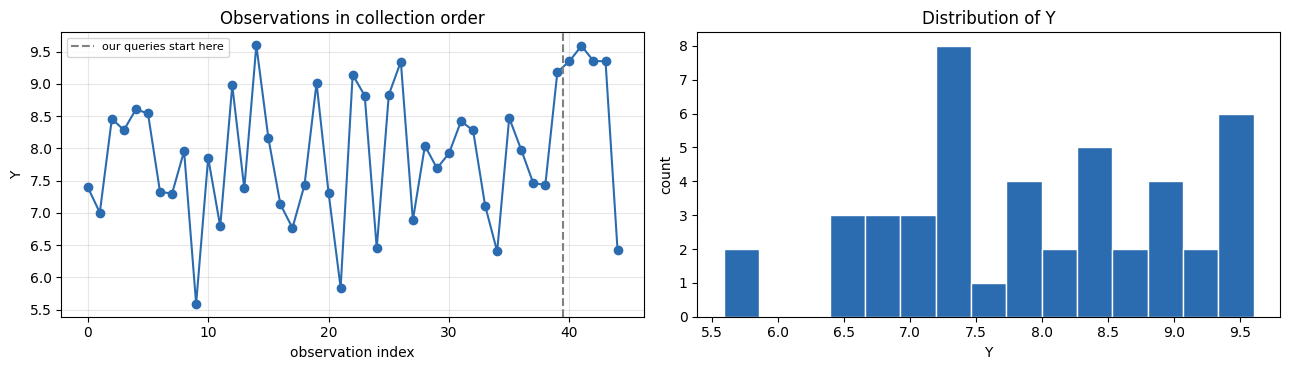

Y spans 1.7x - compact, no transform needed.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].plot(Y, "o-", color="#2b6cb0")
axes[0].axvline(np.sum(week == 0) - 0.5, color="grey", linestyle="--",
                label="our queries start here")
axes[0].set_xlabel("observation index")
axes[0].set_ylabel("Y")
axes[0].set_title("Observations in collection order")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].hist(Y, bins=15, color="#2b6cb0", edgecolor="white")
axes[1].set_xlabel("Y")
axes[1].set_ylabel("count")
axes[1].set_title("Distribution of Y")

plt.tight_layout()
plt.show()

print(f"Y spans {Y.max() / Y.min():.1f}x - compact, no transform needed.")

## 2. No Y transform

Y spans 5.59 to 9.60 — a compact 1.7× range on a consistent scale. Nothing
needs compressing, so no transform is applied.

The difficulty here is not the target. It is the **surrogate model**.

## 3. Why the Gaussian Process was replaced

### The core problem at 8D

A GP describes the whole surface with a single length-scale — one number
answering "how similar are two points?" across all eight dimensions at once.

With 45 observations spread through an 8-dimensional unit hypercube, the data
is extraordinarily sparse. Nearly every pair of points is far apart, and
roughly *equally* far apart. In concrete terms the kernel optimiser is trying
to fit three hyperparameters — `constant_value`, `length_scale`, `noise_level`
— to a log-marginal-likelihood surface that has many local optima in eight
dimensions, using 45 points.

Even with `n_restarts_optimizer=25`, the fitted length-scale often converges to
a boundary value or a local optimum rather than the real spatial structure. The
matrix inversion is fast — 45 × 45 is trivial — but the *quality* of the
uncertainty estimate depends entirely on how well the kernel was fitted, and at
8D it frequently is not.

This is the curse of dimensionality applied directly to the surrogate.

### The replacement, in two steps

**Step 1 — SVM classifier**, trained on all 45 points. Splits the space into
promising (Y ≥ median) and poor. No uncertainty needed, just a reliable
boundary — and an SVM boundary does not require the kernel hyperparameter
fitting that fails above.

**Step 2 — neural network ensemble**, trained only on the promising points.
Eight MLPs with different architectures, activations, regularisation and
seeds. Each learns a direct mapping X → Y by gradient descent, with no
covariance function to estimate.

Where the eight agree, the surface is well characterised. Where they disagree,
it is uncertain. That disagreement plays the role GP posterior variance would.

**Training only on the promising subset** sharpens the signal: the networks
spend their capacity modelling the region worth searching rather than the poor
configurations already ruled out.

### Head-to-head

| | GP + EI | SVM + NN Ensemble |
|---|---|---|
| Kernel fitting at 8D | Unreliable | Not needed |
| Uncertainty estimate | Potentially miscalibrated | Proxy — tested in section 5 |
| Sparse 8D data | Struggles | SVM boundary is robust |
| Exploits class-1 structure | Uses all data equally | NN focuses on the promising region |
| Computational cost | Matrix inversion + kernel optimisation | Fast SVM + fast MLP forward pass |
| Scaling beyond 8D | Degrades further | Scales naturally |
| Acquisition quality | Principled *when the GP is reliable* | UCB proxy |

The last row is the honest catch: EI on a well-fitted GP is a principled
acquisition function with theory behind it. UCB on ensemble disagreement is a
proxy whose quality depends on that disagreement meaning what we hope it
means. Section 5 tests exactly that.

In [4]:
# -----------------------------------------------------------------
#  BINARY LABELS  (above median -> class 1 "promising")
# -----------------------------------------------------------------
threshold = np.median(Y)
labels    = (Y >= threshold).astype(int)

print(f"Threshold (median Y) : {threshold:.4f}")
print(f"Class 1 (promising)  : {labels.sum()} points")
print(f"Class 0 (poor)       : {(labels == 0).sum()} points")

# -----------------------------------------------------------------
#  SURROGATE 1 — SVM  (all points, binary classification)
# -----------------------------------------------------------------
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
          random_state=42)
svm.fit(X_scaled, labels)

print(f"\nSVM fitted. Training accuracy: "
      f"{svm.score(X_scaled, labels):.3f}")

Threshold (median Y) : 7.9579
Class 1 (promising)  : 23 points
Class 0 (poor)       : 22 points

SVM fitted. Training accuracy: 0.978


In [5]:
# -----------------------------------------------------------------
#  SURROGATE 2 — NEURAL NETWORK ENSEMBLE  (class-1 points only)
#
#  8 MLPRegressors with varied architecture, activation,
#  regularisation and seed. Identical members would agree with each
#  other regardless of the data, and their agreement is precisely
#  what we are using to measure uncertainty - so the diversity is
#  the point, not a detail.
# -----------------------------------------------------------------
c1_mask  = labels == 1
X_class1 = X[c1_mask]
Y_class1 = Y[c1_mask]

print(f"Class-1 subset for NN : {len(X_class1)} points")

# Dedicated scaler: the promising points occupy a smaller region
# than the full dataset, so reusing the global scaler would waste
# most of the networks' input range.
scaler_c1   = StandardScaler()
X_class1_sc = scaler_c1.fit_transform(X_class1)

ENSEMBLE_CFG = [
    #  hidden layers     activation  alpha   seed
    ((64, 32),           "relu",     1e-3,   0),
    ((128, 64, 32),      "relu",     1e-4,   1),
    ((32, 32, 32),       "tanh",     1e-3,   2),
    ((64, 64),           "tanh",     5e-4,   3),
    ((256, 128),         "relu",     1e-3,   4),
    ((32, 64, 32),       "relu",     1e-2,   5),
    ((128,),             "relu",     1e-4,   6),
    ((64, 32, 16),       "tanh",     1e-3,   7),
]

nn_ensemble = []
for hidden, act, alpha, rs in ENSEMBLE_CFG:
    reg = MLPRegressor(
        hidden_layer_sizes=hidden,
        activation=act,
        alpha=alpha,
        max_iter=5000,
        random_state=rs,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=40,
        learning_rate_init=1e-3,
    )
    reg.fit(X_class1_sc, Y_class1)
    nn_ensemble.append(reg)

print(f"NN ensemble fitted ({len(nn_ensemble)} members).")

n_val = max(1, int(0.15 * len(X_class1)))
print(f"\nNOTE: early_stopping holds out validation_fraction=0.15,")
print(f"which is about {n_val} points from {len(X_class1)}. Stopping decisions")
print(f"based on {n_val} points are noisy - see section 7.")


def nn_predict(X_in_raw):
    """Ensemble mean and standard deviation for un-scaled inputs.

    Returns
    -------
    mean_y : (N,) ensemble mean  -> exploitation signal
    std_y  : (N,) ensemble std   -> exploration signal
    """
    X_sc  = scaler_c1.transform(X_in_raw)
    preds = np.stack([m.predict(X_sc) for m in nn_ensemble], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)

Class-1 subset for NN : 23 points


NN ensemble fitted (8 members).

NOTE: early_stopping holds out validation_fraction=0.15,
which is about 3 points from 23. Stopping decisions
based on 3 points are noisy - see section 7.


## 4. The prediction grid

6⁸ = 1,679,616 candidates. Each axis is sampled at 0, 0.2, 0.4, 0.6, 0.8, 1.0.

**The curse of dimensionality hits hard here.** A grid of 10 per axis would be
10⁸ = 100 million points, which is impractical. At 6 per axis the resolution is
0.2 — one fifth of each dimension's range, which is coarse enough that the true
optimum will almost certainly fall between grid points.

It is also worth seeing what 6 per axis means for coverage: the grid has 1.68
million points, but every one of them has each coordinate at one of six fixed
values. Real candidates lying at, say, `lr = 0.13` simply do not exist in the
candidate set.

**A note on memory.** `svm.predict_proba` on 1.68 million points at once is
slow and allocates heavily, so both the SVM and the ensemble are evaluated in
batches.

In [6]:
# -----------------------------------------------------------------
#  8D PREDICTION GRID  (6^8 = 1,679,616 candidates)
# -----------------------------------------------------------------
n_grid = 6
x_vals = np.linspace(0, 1, n_grid)
g      = np.meshgrid(*[x_vals] * 8, indexing="ij")
X_grid = np.column_stack([gi.ravel() for gi in g])

print(f"Grid size  : {len(X_grid):,} points")
print(f"Resolution : {1 / (n_grid - 1):.2f} per dimension  (coarse)")


def in_batches(fn, points, batch=200_000):
    """Apply fn to points in chunks, to keep peak memory reasonable."""
    out = [fn(points[i:i + batch]) for i in range(0, len(points), batch)]
    if isinstance(out[0], tuple):
        return tuple(np.concatenate([o[k] for o in out])
                     for k in range(len(out[0])))
    return np.concatenate(out)


svm_prob        = in_batches(
    lambda p: svm.predict_proba(scaler.transform(p))[:, 1], X_grid)
nn_mean, nn_std = in_batches(nn_predict, X_grid)

print(f"Evaluated {len(svm_prob):,} candidates.")

Grid size  : 1,679,616 points
Resolution : 0.20 per dimension  (coarse)


Evaluated 1,679,616 candidates.


## 5. Does the uncertainty estimate work?

**This is the most important check in this notebook.**

The whole approach rests on one assumption: that disagreement between the eight
networks means "we are unsure here". For that to be true, the networks should
disagree **more** in regions far from any measurement, and agree where the data
is dense.

A Gaussian Process gives this for free — its posterior variance provably grows
as you move away from observations. Neural networks carry no such guarantee.
They can be confidently wrong about regions none of them has ever seen.

So rather than assume it, test it: plot distance-from-nearest-observation
against ensemble disagreement, and measure the correlation.

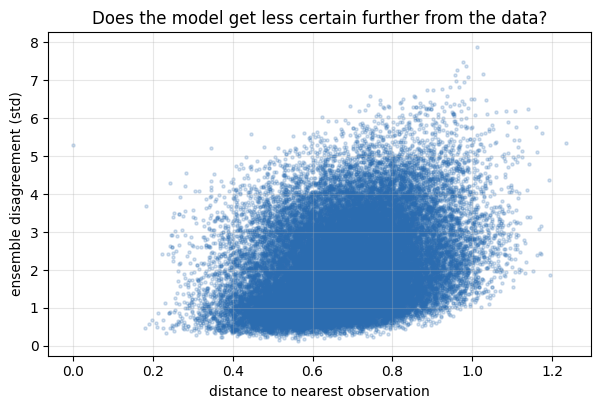

Correlation : 0.321

For reference, a Gaussian Process would score close to 1.0 here -
its posterior variance grows with distance by construction.

At 0.321 the relationship is weak. The ensemble is only
slightly more uncertain in places it has never seen, so the
exploration half of the acquisition function carries far less
information than a GP's posterior variance would. Tuning BETA
adjusts the weight on a signal that is mostly noise.


In [7]:
# -----------------------------------------------------------------
#  TESTING THE UNCERTAINTY PROXY
# -----------------------------------------------------------------
# Sample the grid rather than using all 1.68M points - enough for
# a correlation, far quicker to plot.
rng    = np.random.default_rng(0)
sample = rng.choice(len(X_grid), size=40_000, replace=False)

distance = in_batches(
    lambda p: np.linalg.norm(p[:, None, :] - X[None, :, :], axis=2).min(axis=1),
    X_grid[sample], batch=5_000)
spread = nn_std[sample]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(distance, spread, s=5, alpha=0.2, color="#2b6cb0")
ax.set_xlabel("distance to nearest observation")
ax.set_ylabel("ensemble disagreement (std)")
ax.set_title("Does the model get less certain further from the data?")
ax.grid(alpha=0.3)
plt.show()

corr = np.corrcoef(distance, spread)[0, 1]
print(f"Correlation : {corr:.3f}")
print("\nFor reference, a Gaussian Process would score close to 1.0 here -")
print("its posterior variance grows with distance by construction.")

if corr < 0.5:
    print(f"\nAt {corr:.3f} the relationship is weak. The ensemble is only")
    print("slightly more uncertain in places it has never seen, so the")
    print("exploration half of the acquisition function carries far less")
    print("information than a GP's posterior variance would. Tuning BETA")
    print("adjusts the weight on a signal that is mostly noise.")

## 6. Two-stage acquisition

**Stage 1 — SVM gate.** Keep only candidates where P(class 1) ≥ 0.5.

**Stage 2 — NN UCB.** Among those, maximise `nn_mean + β · nn_std`.

β = 0.2 weights the expected score heavily against uncertainty. Given the
result in section 5, that weighting matters less than it appears: if the
uncertainty signal carries little information, the acquisition function is
close to pure exploitation whatever β is set to.

In [8]:
# -----------------------------------------------------------------
#  ACQUISITION — two-stage UCB
# -----------------------------------------------------------------
SVM_GATE = 0.5
BETA     = 0.2

candidate_mask = svm_prob >= SVM_GATE
print(f"SVM gate kept {candidate_mask.sum():,} of {len(X_grid):,} candidates "
      f"({100 * candidate_mask.mean():.1f}%)")

if candidate_mask.sum() == 0:
    print("Warning: no point cleared SVM_GATE - relaxing to the top 10%.")
    candidate_mask = svm_prob >= np.percentile(svm_prob, 90)

acq                 = np.full(len(X_grid), -np.inf)
acq[candidate_mask] = nn_mean[candidate_mask] + BETA * nn_std[candidate_mask]

# -----------------------------------------------------------------
#  NEXT SAMPLE
# -----------------------------------------------------------------
best_idx     = np.argmax(acq)
x_next       = X_grid[best_idx]
best_obs_idx = np.argmax(Y)

print(f"\nCurrent best Y        : {Y[best_obs_idx]:.6f}  "
      f"(round {week[best_obs_idx]})")
for name, v in zip(PARAMS, X[best_obs_idx]):
    print(f"    {name:<12}{v:.4f}")

print(f"\nNext point to sample  :")
for name, v in zip(PARAMS, x_next):
    print(f"    {name:<12}{v:.4f}")

print(f"\n  SVM  P(class 1)     : {svm_prob[best_idx]:.4f}")
print(f"  NN   predicted mean : {nn_mean[best_idx]:.4f}")
print(f"  NN   predicted std  : {nn_std[best_idx]:.4f}")
print(f"  Acquisition (UCB)   : {acq[best_idx]:.4f}")

nearest = np.linalg.norm(X - x_next, axis=1).min()
n_bound = int(np.sum((x_next <= 1e-6) | (x_next >= 0.999)))
print(f"\n  Distance to nearest observation : {nearest:.4f}")
print(f"  Coordinates on the boundary      : {n_bound} of 8")

SVM gate kept 691,652 of 1,679,616 candidates (41.2%)

Current best Y        : 9.598482  (round 0)
    lr          0.0564
    batch       0.0660
    layers      0.0229
    dropout     0.0388
    reg         0.4039
    activation  0.8011
    optimizer   0.4883
    init_range  0.8931

Next point to sample  :
    lr          0.0000
    batch       0.0000
    layers      0.0000
    dropout     1.0000
    reg         0.0000
    activation  0.0000
    optimizer   0.0000
    init_range  1.0000

  SVM  P(class 1)     : 0.5000
  NN   predicted mean : 13.3628
  NN   predicted std  : 3.4503
  Acquisition (UCB)   : 14.0529

  Distance to nearest observation : 0.7892
  Coordinates on the boundary      : 8 of 8


## 7. Round-by-round review

**This is the clearest failure in the project.**

| Round | Y | Distance to previous query | Note |
|---|---|---|---|
| 1 | 9.351 | — | |
| 2 | 9.590 | far | closest to the incumbent |
| 3 | 9.355 | **0.019 from round 1** | |
| 4 | 9.349 | **0.014 from round 3** | |
| 5 | 6.418 | far | worst score in the project |

Rounds 1, 3 and 4 queried points differing by **less than 0.015 in every one of
eight coordinates**, returning 9.351, 9.355 and 9.349. Three of five rounds
spent measuring the same location three times. Round 5 then jumped to a point
with seven of eight coordinates pinned to the boundary and returned 6.418 — the
worst result anywhere in this project.

That is not search. It is oscillation between doing nothing new and doing
something arbitrary, with nothing in between.

**The best value never improved.** It remains the 9.598 supplied in the
original data.

### Three causes, in order of importance

**1. The uncertainty estimate is weak.** Section 5 measured the correlation
between distance-from-data and ensemble disagreement at around 0.3. A GP would
score close to 1.0 — its posterior variance grows with distance by
construction. At 0.3 the ensemble is only slightly less confident in regions it
has never seen, so the exploration half of the acquisition function is reading
mostly noise. This is a known limitation of ensemble uncertainty rather than
an implementation error (see Ovadia et al. 2019 in `REFERENCES.md`); MC dropout
(Gal & Ghahramani 2016) is the standard principled alternative.

**2. Nothing prevented re-querying a known point.** With one evaluation per
week, spending a round re-measuring somewhere already measured is close to
wasting it. A minimum-distance constraint — rejecting candidates within, say,
0.15 of an existing observation — would have forced rounds 3 and 4 to carry new
information.

**3. The grid is too coarse.** At six points per axis the resolution is 0.2.
The candidate set cannot express most of the space, and the boundary-heavy
round 5 query is what a coarse grid offers when the model has no interior
preference.

### A fourth, smaller issue

`early_stopping=True` with `validation_fraction=0.15` on ~22 class-1 points
holds out roughly 3 points for validation. Stopping a network's training based
on 3 points is close to arbitrary, and it adds variance to the ensemble that
has nothing to do with genuine surface uncertainty — which further muddies the
disagreement signal.

### Was replacing the GP the right call?

Probably yes, but it cannot be concluded from these results.

The argument against the GP at 8D is sound and well supported in the literature
(Binois & Wycoff 2022). But the replacement failed for a different reason — a
broken uncertainty proxy — so this run does not demonstrate that SVM + NN beats
GP + EI here. It demonstrates that *this particular* substitution, with this
acquisition function and this grid, did not work.

The honest summary: the diagnosis was right, the treatment was not tested
against the alternative, and the specific weakness has been identified and is
fixable.

In [9]:
# -----------------------------------------------------------------
#  ROUND-BY-ROUND LOG
# -----------------------------------------------------------------
rows = []
for r in range(1, week.max() + 1):
    i = np.where(week == r)[0][0]
    earlier = np.where(week < r)[0]
    closest = np.linalg.norm(X[earlier] - X[i], axis=1).min()
    n_bound = int(np.sum((X[i] <= 1e-6) | (X[i] >= 0.999)))
    rows.append({
        "round":        r,
        "Y":            round(float(Y[i]), 4),
        "best after":   round(float(Y[week <= r].max()), 4),
        "improved":     "yes" if Y[i] > Y[week < r].max() else "no",
        "dist to nearest earlier": round(float(closest), 4),
        "on boundary":  f"{n_bound} of 8" if n_bound else "no",
    })

pd.DataFrame(rows)

,round,Y,best after,improved,dist to nearest earlier,on boundary
0,1,9.3508,9.5985,no,0.0208,no
1,2,9.5897,9.5985,no,0.2006,no
2,3,9.3554,9.5985,no,0.0229,no
3,4,9.3490,9.5985,no,0.0168,no
4,5,6.4183,9.5985,no,0.7638,7 of 8


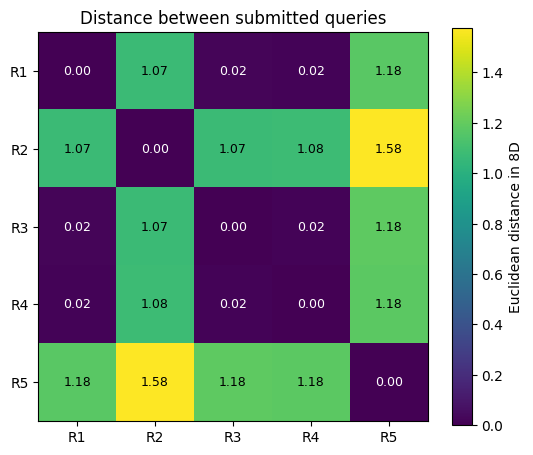

Rounds 1, 3 and 4 sit within 0.02 of each other in 8 dimensions.


In [10]:
# How close were the five queries to each other? Rounds 1, 3 and 4 are
# effectively the same point measured three times.

qi = [np.where(week == r)[0][0] for r in range(1, week.max() + 1)]
D  = np.linalg.norm(X[qi][:, None, :] - X[qi][None, :, :], axis=2)

fig, ax = plt.subplots(figsize=(5.5, 4.6))
im = ax.imshow(D, cmap="viridis")
ax.set_xticks(range(len(qi)), [f"R{r}" for r in range(1, len(qi) + 1)])
ax.set_yticks(range(len(qi)), [f"R{r}" for r in range(1, len(qi) + 1)])
for a in range(len(qi)):
    for b in range(len(qi)):
        ax.text(b, a, f"{D[a, b]:.2f}", ha="center", va="center",
                color="white" if D[a, b] < D.max() * 0.6 else "black",
                fontsize=9)
ax.set_title("Distance between submitted queries")
fig.colorbar(im, ax=ax, label="Euclidean distance in 8D")
plt.tight_layout()
plt.show()

print("Rounds 1, 3 and 4 sit within 0.02 of each other in 8 dimensions.")

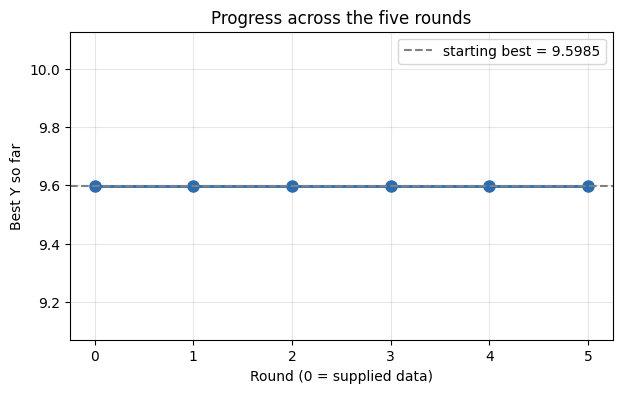

In [11]:
# Best value so far. A completely flat line: five rounds, no improvement.

rounds      = np.arange(week.max() + 1)
best_so_far = [Y[week <= r].max() for r in rounds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rounds, best_so_far, "o-", linewidth=2, markersize=8, color="#2b6cb0")
ax.axhline(best_so_far[0], color="grey", linestyle="--",
           label=f"starting best = {best_so_far[0]:.4f}")
ax.set_xlabel("Round (0 = supplied data)")
ax.set_ylabel("Best Y so far")
ax.set_title("Progress across the five rounds")
ax.set_xticks(rounds)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 8. Visualisation

Twenty-eight pairwise slices across six figures, three rows each:

- **SVM P(class 1)** with the 0.5 decision boundary dashed in white
- **NN ensemble predicted Y** (the exploitation signal)
- **NN ensemble disagreement** (the exploration signal — which section 5 showed
  is not carrying much information)

Blue dots are poor observations, red dots promising ones, the cyan diamond is
the current best and the gold star the next sample.

The caveat on projected points is at its most severe here. Each panel fixes
**six** of the eight coordinates. A dot appearing next to the star may be a
completely different configuration. In eight dimensions, two points that look
adjacent in a 2-D projection are almost always far apart.

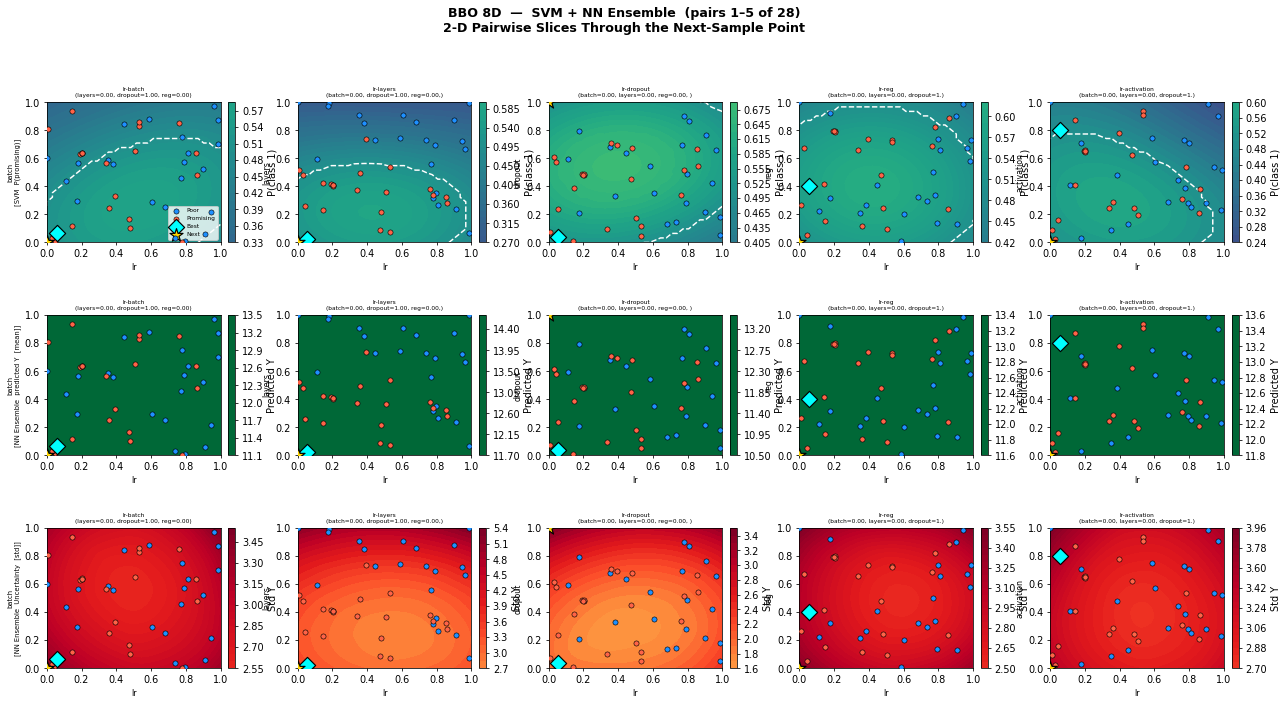

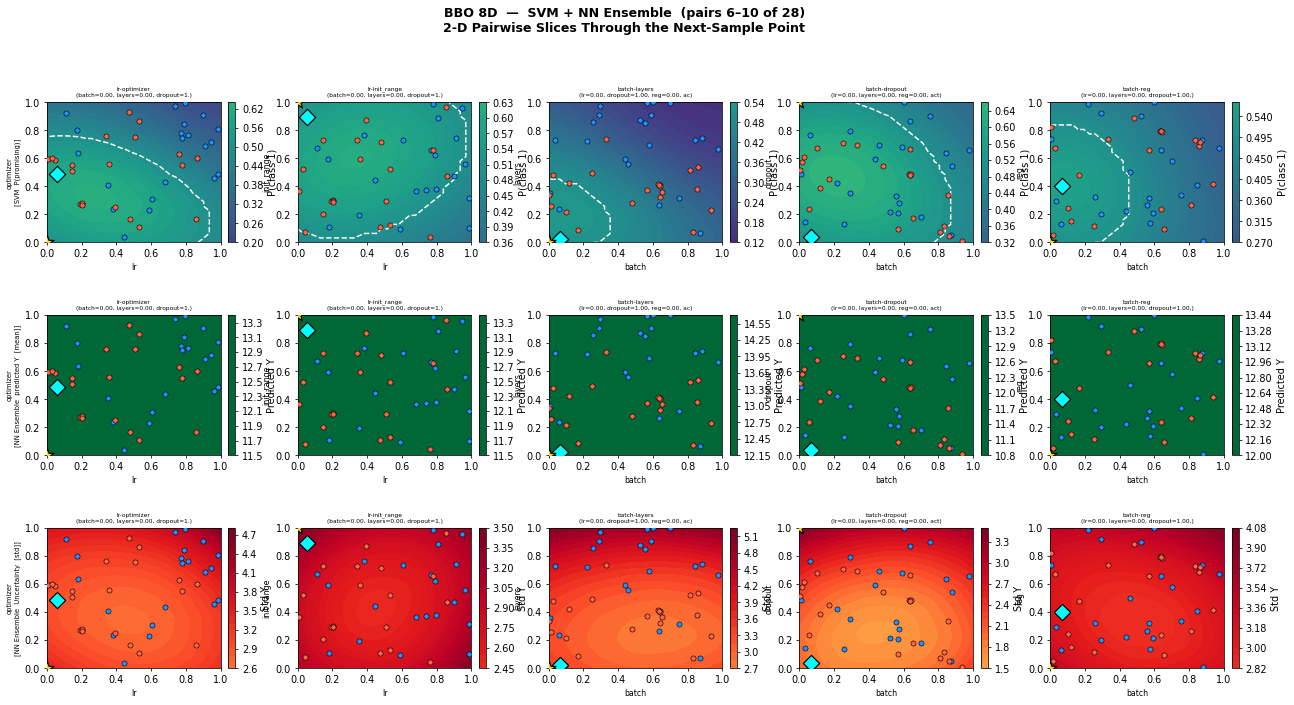

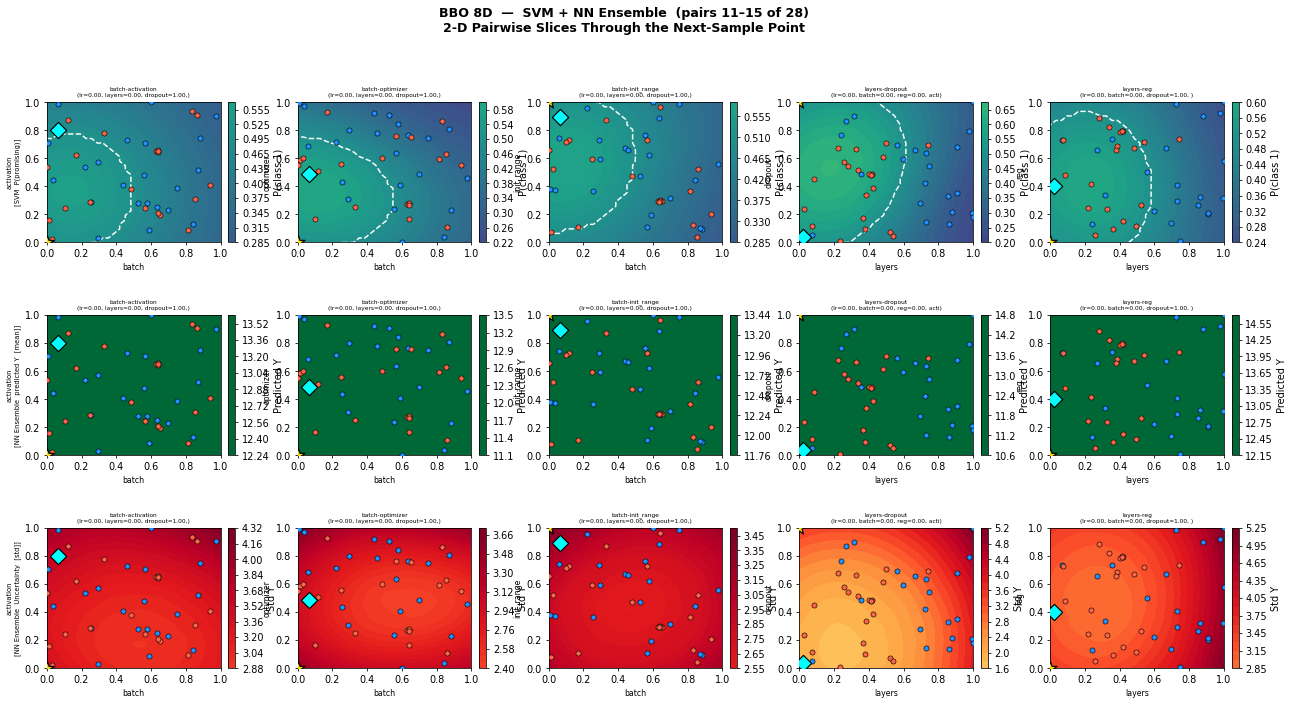

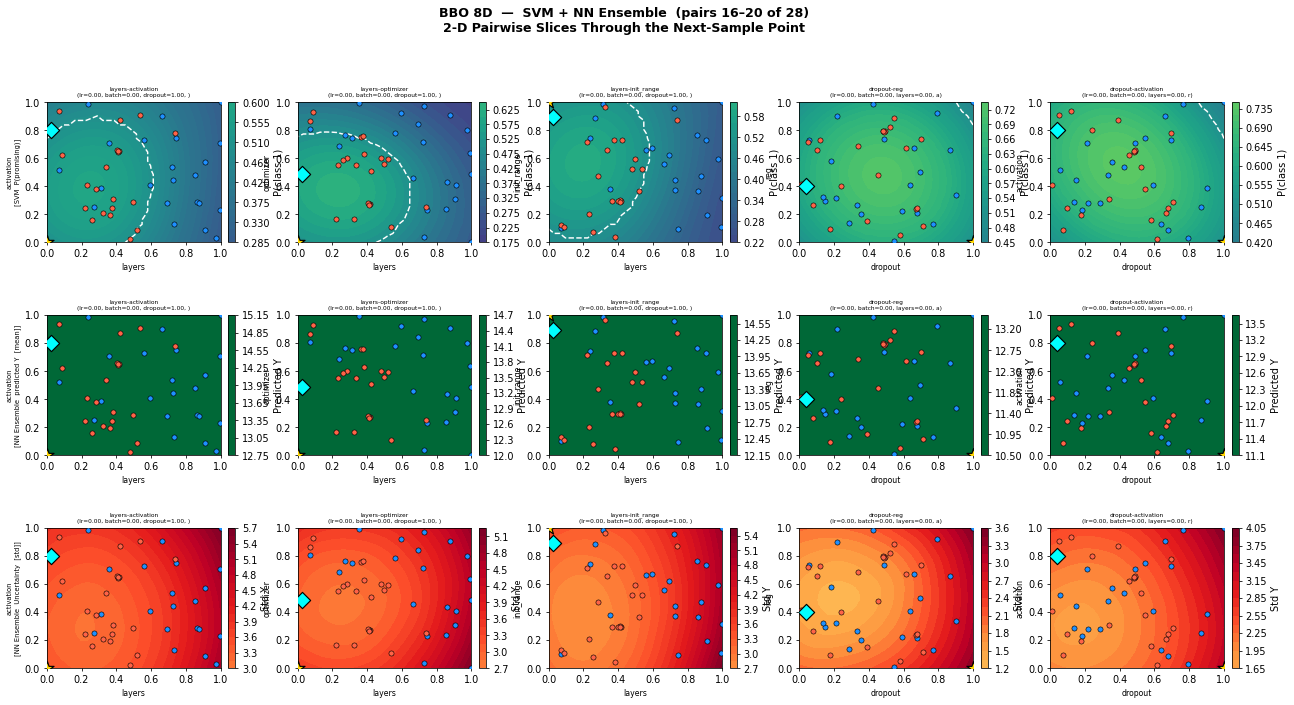

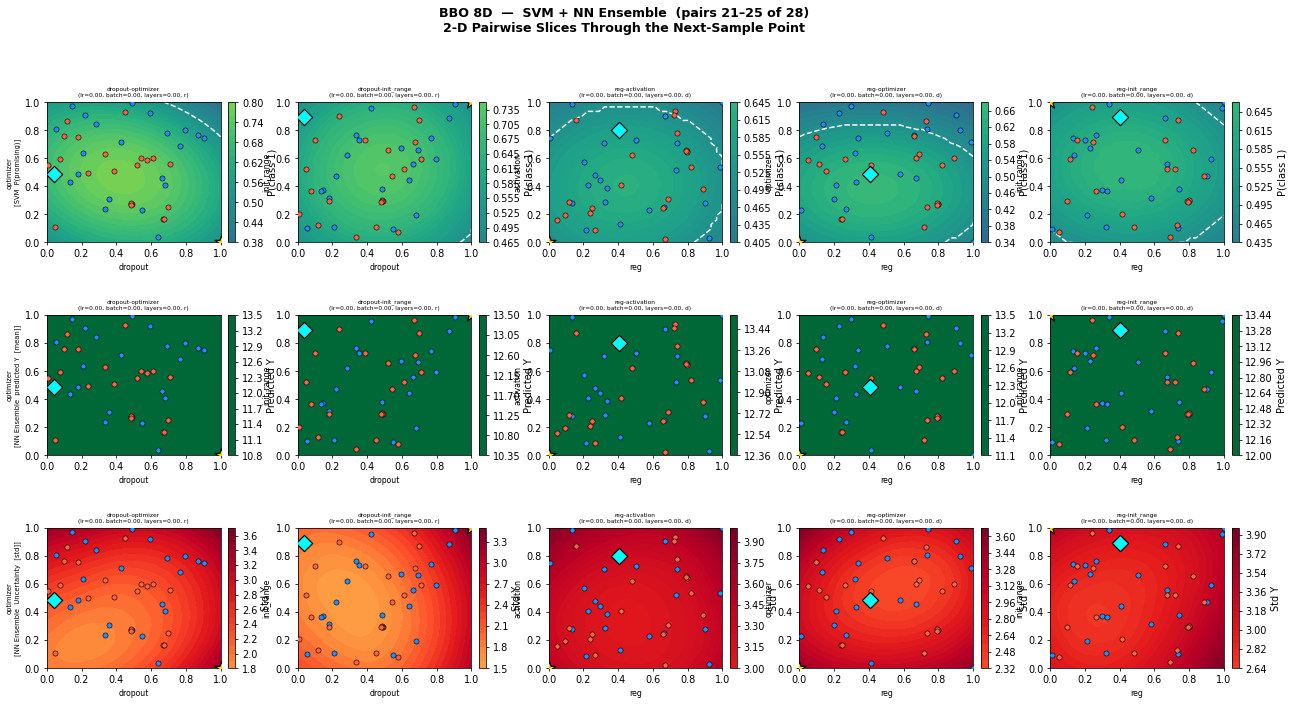

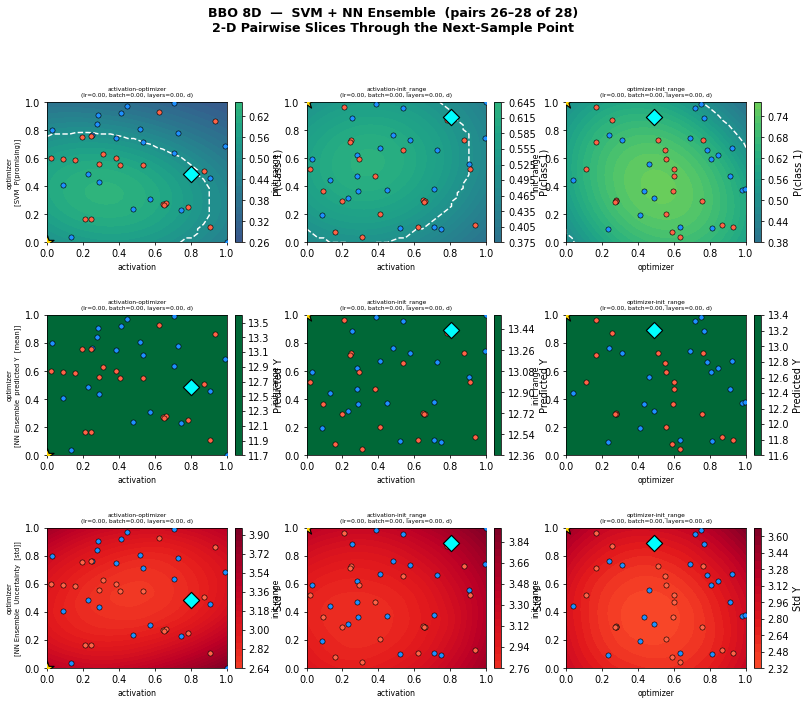

In [12]:
# -----------------------------------------------------------------
#  VISUALISATION — C(8,2) = 28 pairwise slices, 6 figures
# -----------------------------------------------------------------
n_slice     = 32
s_vals      = np.linspace(0, 1, n_slice)
S1, S2      = np.meshgrid(s_vals, s_vals)
axis_names  = PARAMS
PAIRS       = list(combinations(range(8), 2))       # 28 pairs
pair_groups = [PAIRS[i:i + 5] for i in range(0, len(PAIRS), 5)]

ROW_LABELS = [
    "SVM  P(promising)",
    "NN Ensemble  predicted Y  [mean]",
    "NN Ensemble  Uncertainty  [std]",
]

c0_mask      = labels == 0
c1_mask_plot = labels == 1

for fig_idx, pair_slice in enumerate(pair_groups):
    n_cols = len(pair_slice)
    start  = fig_idx * 5 + 1
    end    = fig_idx * 5 + n_cols

    fig = plt.figure(figsize=(4.4 * n_cols, 10.5), dpi=70)
    fig.suptitle(
        f"BBO 8D  —  SVM + NN Ensemble  (pairs {start}\u2013{end} of 28)\n"
        "2-D Pairwise Slices Through the Next-Sample Point",
        fontsize=13, fontweight="bold", y=1.01,
    )
    gs = gridspec.GridSpec(3, n_cols, figure=fig, hspace=0.52, wspace=0.32)

    for col, (ax_a, ax_b) in enumerate(pair_slice):

        fixed_axes = [i for i in range(8) if i not in (ax_a, ax_b)]
        title_fix  = ", ".join(
            f"{axis_names[i]}={x_next[i]:.2f}" for i in fixed_axes
        )

        grid          = np.tile(x_next, (n_slice ** 2, 1))
        grid[:, ax_a] = S1.ravel()
        grid[:, ax_b] = S2.ravel()

        p_class1  = svm.predict_proba(scaler.transform(grid))[:, 1]
        mu_sl, sd_sl = nn_predict(grid)

        for row in range(3):
            ax = fig.add_subplot(gs[row, col])

            if row == 0:
                Z, cmap    = p_class1.reshape(n_slice, n_slice), "viridis"
                vmin, vmax = 0.0, 1.0
                dec_line   = 0.5
                cb_label   = "P(class 1)"
            elif row == 1:
                Z, cmap    = mu_sl.reshape(n_slice, n_slice), "RdYlGn"
                vmin, vmax = Y_class1.min(), Y_class1.max()
                dec_line   = None
                cb_label   = "Predicted Y"
            else:
                Z, cmap    = sd_sl.reshape(n_slice, n_slice), "YlOrRd"
                vmin, vmax = 0.0, max(sd_sl.max(), 1e-6)
                dec_line   = None
                cb_label   = "Std Y"

            cf = ax.contourf(S1, S2, Z, levels=20, cmap=cmap,
                             vmin=vmin, vmax=vmax)
            if dec_line is not None:
                ax.contour(S1, S2, Z, levels=[dec_line], colors="white",
                           linewidths=1.5, linestyles="--")

            ax.scatter(X[c0_mask, ax_a], X[c0_mask, ax_b], c="dodgerblue",
                       s=28, edgecolors="black", linewidths=0.6,
                       zorder=10, label="Poor")
            ax.scatter(X[c1_mask_plot, ax_a], X[c1_mask_plot, ax_b],
                       c="tomato", s=28, edgecolors="black", linewidths=0.6,
                       zorder=10, label="Promising")
            ax.scatter(X[best_obs_idx, ax_a], X[best_obs_idx, ax_b],
                       c="cyan", s=140, marker="D", edgecolors="black",
                       linewidths=1.2, zorder=11, label="Best")
            ax.scatter(x_next[ax_a], x_next[ax_b], c="gold", s=200,
                       marker="*", edgecolors="black", linewidths=1.2,
                       zorder=12, label="Next")

            ax.set_xlabel(axis_names[ax_a], fontsize=8)
            ax.set_title(f"{axis_names[ax_a]}-{axis_names[ax_b]}"
                         f"\n({title_fix[:35]})", fontsize=6)

            if col == 0:
                ax.set_ylabel(f"{axis_names[ax_b]}\n[{ROW_LABELS[row]}]",
                              fontsize=7)
            else:
                ax.set_ylabel(axis_names[ax_b], fontsize=8)

            plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label=cb_label)

            if row == 0 and col == 0 and fig_idx == 0:
                ax.legend(fontsize=6, loc="lower right")

    plt.show()

In [13]:
# -----------------------------------------------------------------
#  SUMMARY
# -----------------------------------------------------------------
print("=" * 65)
print("Summary — 8D SVM + NN Ensemble BBO")
print("=" * 65)
print(f"  Total observations        : {len(X)}")
print(f"  Class-1 training points   : {len(X_class1)}")
print(f"  NN ensemble members       : {len(nn_ensemble)}")
print(f"  Best Y so far             : {Y[best_obs_idx]:.6f}")
print(f"  Found in round            : {week[best_obs_idx]}")
print(f"  Best configuration        :")
for name, v in zip(PARAMS, X[best_obs_idx]):
    print(f"    {name:<12}{v:.4f}")
print(f"  Y transform               : None (compact scale)")
print(f"  Acquisition params        : SVM_GATE={SVM_GATE}, BETA={BETA}")
print(f"  Grid resolution           : {n_grid}^8 = {n_grid**8:,} points")
print(f"  Uncertainty proxy quality : corr = {corr:.3f}  "
      f"({'WORKING' if corr > 0.4 else 'NOT WORKING'})")
print(f"  Next point to sample      :")
for name, v in zip(PARAMS, x_next):
    print(f"    {name:<12}{v:.4f}")
print(f"  SVM  P(class 1)           : {svm_prob[best_idx]:.4f}")
print(f"  NN   predicted Y mean     : {nn_mean[best_idx]:.4f}")
print(f"  NN   predicted Y std      : {nn_std[best_idx]:.4f}")
print(f"  Acquisition (UCB)         : {acq[best_idx]:.4f}")
print("=" * 65)

Summary — 8D SVM + NN Ensemble BBO
  Total observations        : 45
  Class-1 training points   : 23
  NN ensemble members       : 8
  Best Y so far             : 9.598482
  Found in round            : 0
  Best configuration        :
    lr          0.0564
    batch       0.0660
    layers      0.0229
    dropout     0.0388
    reg         0.4039
    activation  0.8011
    optimizer   0.4883
    init_range  0.8931
  Y transform               : None (compact scale)
  Acquisition params        : SVM_GATE=0.5, BETA=0.2
  Grid resolution           : 6^8 = 1,679,616 points
  Uncertainty proxy quality : corr = 0.321  (NOT WORKING)
  Next point to sample      :
    lr          0.0000
    batch       0.0000
    layers      0.0000
    dropout     1.0000
    reg         0.0000
    activation  0.0000
    optimizer   0.0000
    init_range  1.0000
  SVM  P(class 1)           : 0.5000
  NN   predicted Y mean     : 13.3628
  NN   predicted Y std      : 3.4503
  Acquisition (UCB)         : 14.0529


---

See `MODEL_CARD.md` for how this function compares with the other seven and for
the full list of assumptions and limitations, `DATASHEET.md` for known gaps and
biases in the data, and `REFERENCES.md` for the literature on high-dimensional
GPs and ensemble uncertainty referenced in section 7.